Install library

In [ ]:
!pip install tensorflow kaggle matplotlib

Upload Kaggle API

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"yopimjm","key":"10b97db61f504af369f270cbeae918e6"}'}

Setup Kaggle di Colab

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Download dataset

In [ ]:
!kaggle datasets download -d asdasdasasdas/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip garbage-classification.zip

Archive:  garbage-classification.zip
replace Garbage classification/Garbage classification/cardboard/cardboard1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Garbage classification/Garbage classification/cardboard/cardboard10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


PREPROCESS DATA

In [ ]:
import tensorflow as tf
import os

img_size = (224, 224)
batch_size = 32

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Garbage classification/Garbage classification",
    image_size=img_size,
    batch_size=batch_size
)

Found 2527 files belonging to 6 classes.


BUAT MODEL

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

COMPILE MODEL

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRAINING

In [ ]:
model.fit(dataset, epochs=10)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.3332 - loss: 1.6557
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.4828 - loss: 1.3005
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.5884 - loss: 1.1088
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.6522 - loss: 0.9278
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.7230 - loss: 0.7437
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7744 - loss: 0.5981
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8492 - loss: 0.4309
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.8773 - loss: 0.3638
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9062 - loss: 0.2856
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9300 - loss: 0.2088


TEST GAMBAR SAMPAH

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving manfaat-sampah-organik-3-scaled.jpg to manfaat-sampah-organik-3-scaled (5).jpg


Predict gambar

In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_path = list(uploaded.keys())[0]

img = load_img(img_path, target_size=(224,224))
img = img_to_array(img)
img = np.expand_dims(img, axis=0) / 255.0

pred = model.predict(img)
class_index = np.argmax(pred)

print("Hasil prediksi class:", class_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
Hasil prediksi class: 1


UBAH MENJADI ORGANIK vs ANORGANIK

In [ ]:
class_names = ['cardboard','glass','metal','paper','plastic','trash']

organic = ['paper']
inorganic = ['cardboard','glass','metal','plastic','trash']

pred_class = class_names[class_index]

if pred_class in organic:
    print("Sampah ORGANIK")
else:
    print("Sampah ANORGANIK")

Sampah ANORGANIK


CEK DATASET SUDAH ADA

In [ ]:
import os

dataset_path = "/content/Garbage classification/Garbage classification"

print(os.listdir(dataset_path))

['glass', 'plastic', 'paper', 'cardboard', 'metal', 'trash']


UBAH KE MOBILE NET

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

LOAD BASE MODEL (TRANSFER LEARNING)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

BUILD MODEL BARU

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')  # tetap 6 dulu (biar tidak ulang dataset)
])

COMPILE MODEL

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRAINING (LANJUTKAN PROGRES)

In [ ]:
history = model.fit(
    dataset,
    epochs=10
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.5208 - loss: 1.2988
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6347 - loss: 0.9967
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6759 - loss: 0.8735
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7060 - loss: 0.7929
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7222 - loss: 0.7576
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7578 - loss: 0.6797
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7780 - loss: 0.6322
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7792 - loss: 0.5990
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8033 - loss: 0.5632
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8116 - loss: 0.5106


VISUALISASI PROGRES

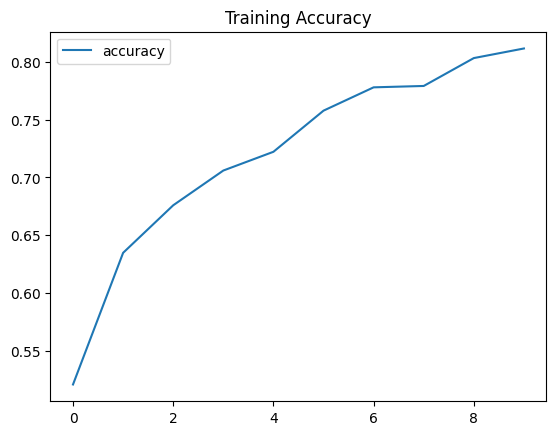

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

TEST GAMBAR SAMPAH

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving manfaat-sampah-organik-3-scaled.jpg to manfaat-sampah-organik-3-scaled (6).jpg


Load gambar yang diupload

In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt

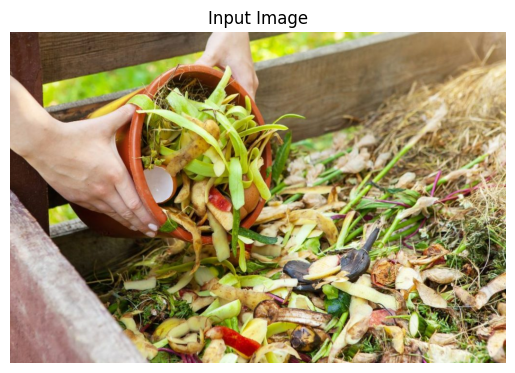

In [ ]:
# ambil file pertama yang diupload
img_path = list(uploaded.keys())[0]

# tampilkan gambar
img = load_img(img_path)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

Preprocessing ke model

In [ ]:
img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

PREDIKSI (MobileNet)

In [ ]:
pred = model.predict(img_array)
class_index = np.argmax(pred)
confidence = np.max(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


LABEL OUTPUT

In [ ]:
class_names = ['cardboard','glass','metal','paper','plastic','trash']

result = class_names[class_index]

print("HASIL PREDIKSI:")
print("Kelas       :", result)
print("Confidence  :", round(confidence * 100, 2), "%")

HASIL PREDIKSI:
Kelas       : metal
Confidence  : 88.58 %


Buat folder baru di Colab

In [ ]:
import os

base_dir = "/content/dataset_fix"

os.makedirs(base_dir + "/organic", exist_ok=True)
os.makedirs(base_dir + "/inorganic", exist_ok=True)

REORGANISASI DATASET

In [ ]:
organic = ["paper"]  # sementara dari dataset
inorganic = ["cardboard", "glass", "metal", "plastic", "trash"]

COPY FILE KE FOLDER BARU

In [ ]:
import shutil
import random

dataset_path = "/content/Garbage classification/Garbage classification"

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    for img in os.listdir(cls_path):
        src = os.path.join(cls_path, img)

        # mapping logic
        if cls in ["paper"]:
            dst = os.path.join(base_dir, "organic", img)
        else:
            dst = os.path.join(base_dir, "inorganic", img)

        shutil.copy(src, dst)

LOAD DATASET BARU (2 KELAS)

In [ ]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset_fix",
    image_size=img_size,
    batch_size=batch_size
)

Found 2527 files belonging to 2 classes.


GANTI MODEL KE 2 KELAS

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

MODEL BARU

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax')  # FIX UTAMA
])

COMPILE MODEL

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRAIN ULANG

In [ ]:
history = model.fit(
    dataset,
    epochs=10
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.8504 - loss: 0.3380
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8916 - loss: 0.2592
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9102 - loss: 0.2208
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9177 - loss: 0.2057
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9145 - loss: 0.2026
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9292 - loss: 0.1813
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9292 - loss: 0.1714
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9493 - loss: 0.1403
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9414 - loss: 0.1331
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9497 - loss: 0.1187


FIX TESTING PREDICTION

In [ ]:
class_names = ["organic", "inorganic"]

In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_path = list(uploaded.keys())[0]

img = load_img(img_path, target_size=(224,224))
img = img_to_array(img)
img = np.expand_dims(img, axis=0) / 255.0

pred = model.predict(img)
class_index = np.argmax(pred)

print("HASIL:", class_names[class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
HASIL: organic


Upload foto sampah

Saving manfaat-sampah-organik-3-scaled.jpg to manfaat-sampah-organik-3-scaled (7).jpg


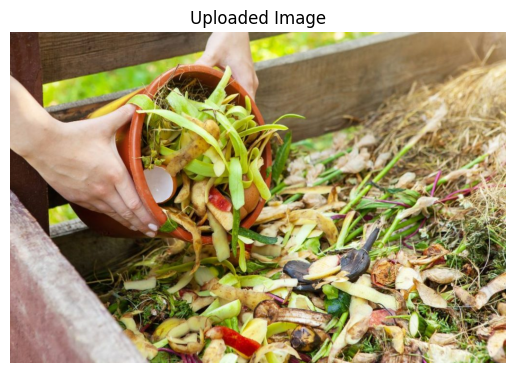

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

HASIL PREDIKSI
Kelas      : organic
Confidence : 100.0 %


In [ ]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# =========================
# 1. UPLOAD IMAGE
# =========================
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# =========================
# 2. DISPLAY IMAGE
# =========================
img = load_img(img_path)
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# =========================
# 3. PREPROCESS IMAGE
# =========================
img = load_img(img_path, target_size=(224,224))
img = img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img / 255.0

# =========================
# 4. PREDICTION
# =========================
pred = model.predict(img)
class_index = np.argmax(pred)
confidence = np.max(pred)

class_names = ["organic", "inorganic"]

# =========================
# 5. OUTPUT RESULT
# =========================
print("\n======================")
print("HASIL PREDIKSI")
print("======================")
print("Kelas      :", class_names[class_index])
print("Confidence :", round(confidence * 100, 2), "%")
print("======================")